NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

# Experiment No. 2
# Exploratory Data Analysis (EDA) on a Real-World Business Dataset

**Dataset:** Netflix Titles Dataset

### Aim
To perform Exploratory Data Analysis (EDA) on a real-world dataset using Python
to understand the dataset's structure, identify trends, detect anomalies,
analyze feature relationships, and generate meaningful business insights.

In [ ]:
%pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Select and Load the Dataset

The Netflix Titles Dataset is used for this experiment.

In [ ]:
# Load the Netflix dataset
df = pd.read_csv("../data/netflix_titles.csv")

# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (8807, 12)


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.nunique().sort_values(ascending=False)

show_id         8807
title           8807
description     8775
cast            7692
director        4528
date_added      1767
country          748
listed_in        514
duration         220
release_year      74
rating            17
type               2
dtype: int64

In [ ]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [ ]:
df["rating"].value_counts().head(15)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
Name: count, dtype: int64

In [ ]:
# Create a copy for EDA
eda_df = df.copy()

# Extract numeric duration
eda_df["duration_value"] = (
    eda_df["duration"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

# Create a year-based numerical feature
eda_df["release_year"] = pd.to_numeric(
    eda_df["release_year"], errors="coerce"
)

eda_df[["title", "type", "release_year", "duration", "duration_value"]].head()

,title,type,release_year,duration,duration_value
0,Dick Johnson Is Dead,Movie,2020,90 min,90.0
1,Blood & Water,TV Show,2021,2 Seasons,2.0
2,Ganglands,TV Show,2021,1 Season,1.0
3,Jailbirds New Orleans,TV Show,2021,1 Season,1.0
4,Kota Factory,TV Show,2021,2 Seasons,2.0


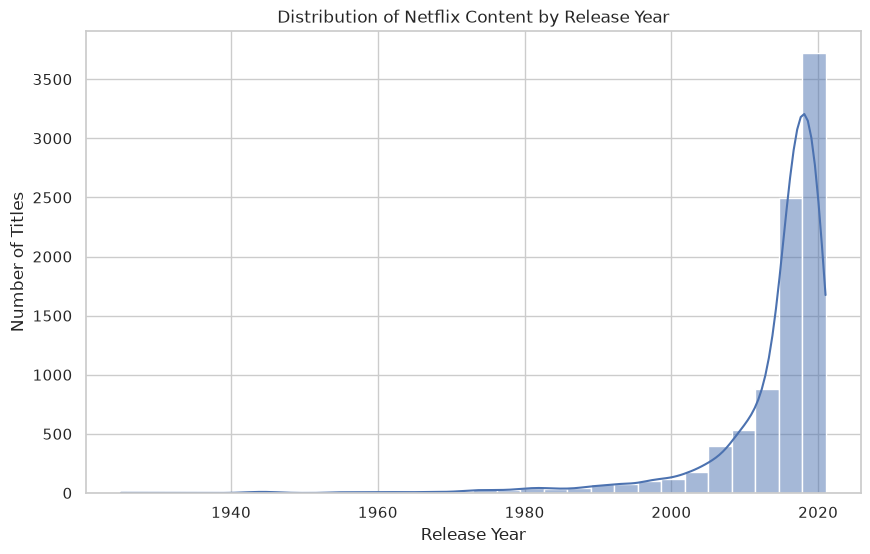

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="release_year",
    bins=30,
    kde=True
)

plt.title("Distribution of Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

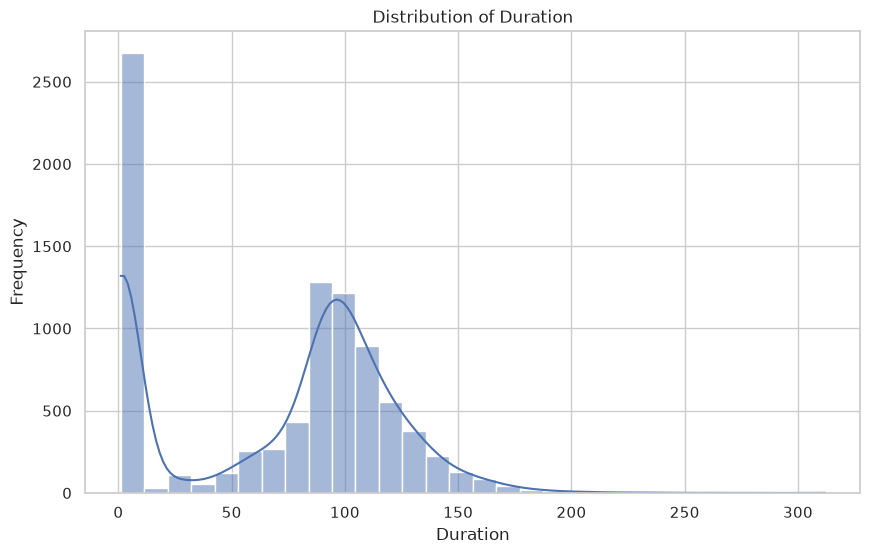

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="duration_value",
    bins=30,
    kde=True
)

plt.title("Distribution of Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

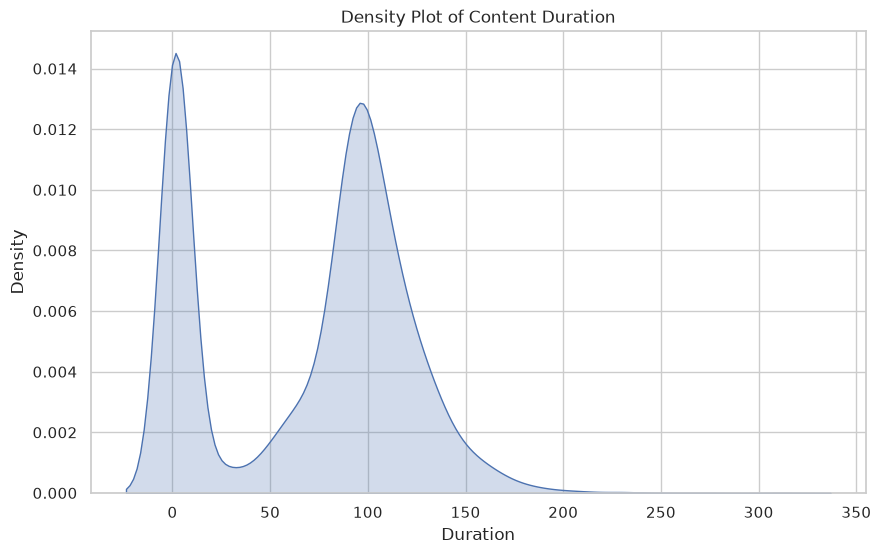

In [ ]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=eda_df,
    x="duration_value",
    fill=True
)

plt.title("Density Plot of Content Duration")
plt.xlabel("Duration")
plt.ylabel("Density")
plt.show()

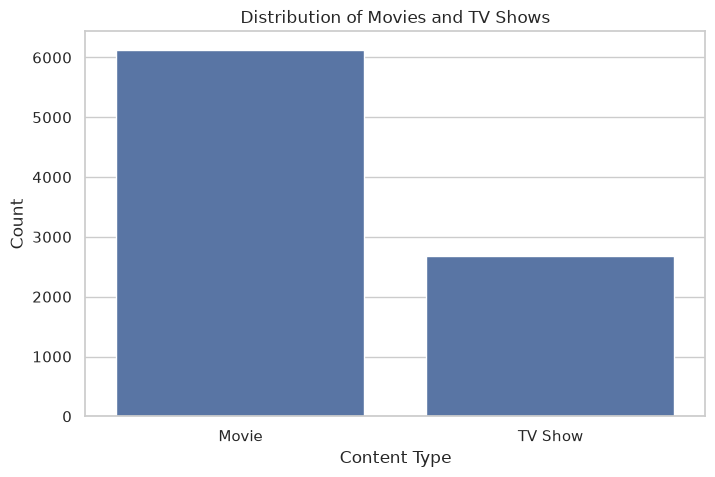

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="type"
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

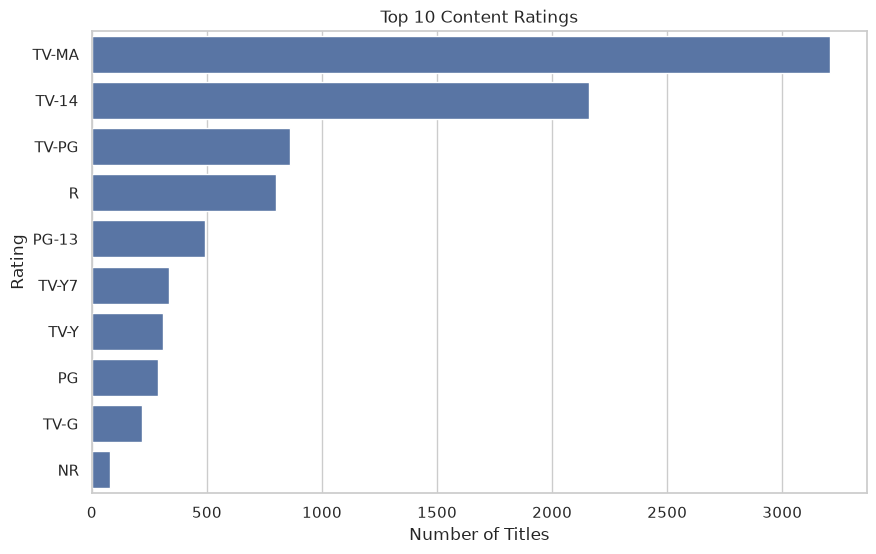

In [ ]:
top_ratings = eda_df["rating"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title("Top 10 Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()

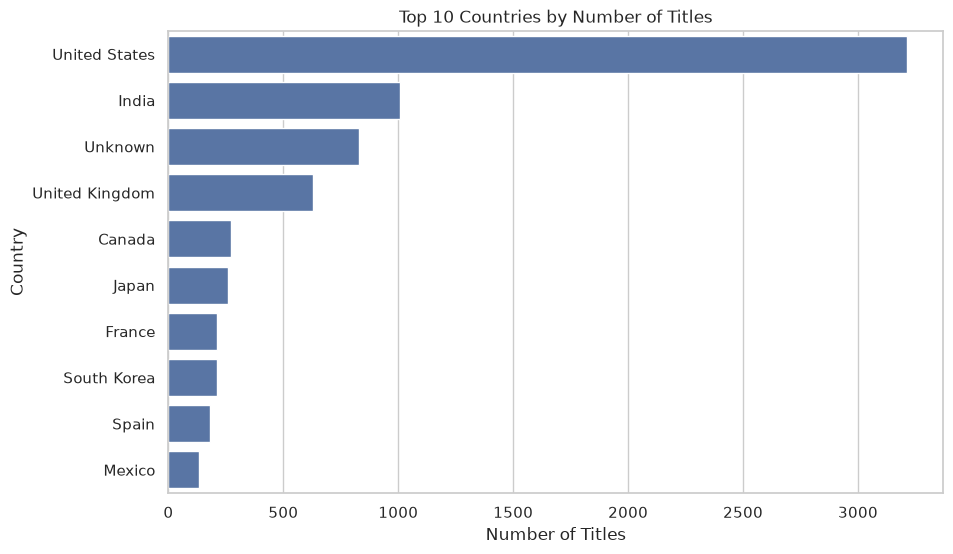

In [ ]:
eda_df["primary_country"] = eda_df["country"].fillna("Unknown").str.split(",").str[0].str.strip()

top_countries = eda_df["primary_country"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [ ]:
numeric_df = eda_df[
    ["release_year", "duration_value"]
].dropna()

correlation_matrix = numeric_df.corr()

correlation_matrix

,release_year,duration_value
release_year,1.000000,-0.249182
duration_value,-0.249182,1.000000


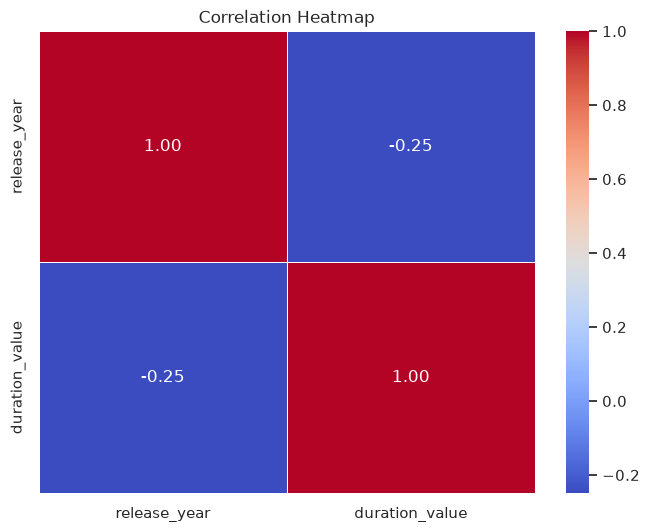

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

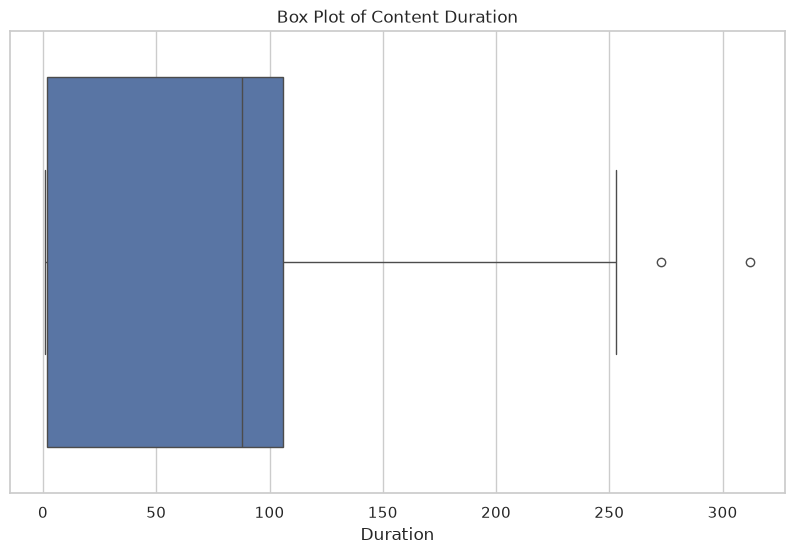

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="duration_value"
)

plt.title("Box Plot of Content Duration")
plt.xlabel("Duration")
plt.show()

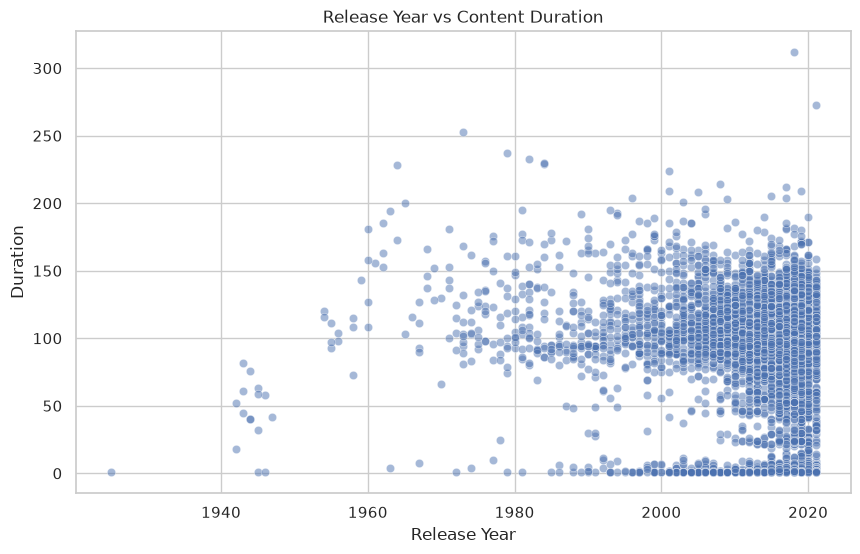

In [ ]:
scatter_df = eda_df[
    ["release_year", "duration_value"]
].dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_df,
    x="release_year",
    y="duration_value",
    alpha=0.5
)

plt.title("Release Year vs Content Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.show()

In [ ]:
print("Content Type Distribution:")
print(eda_df["type"].value_counts())

print("\nRelease Year Statistics:")
print(eda_df["release_year"].describe())

print("\nDuration Statistics:")
print(eda_df["duration_value"].describe())

Content Type Distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Release Year Statistics:
count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

Duration Statistics:
count    8804.000000
mean       69.846888
std        50.814828
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: duration_value, dtype: float64


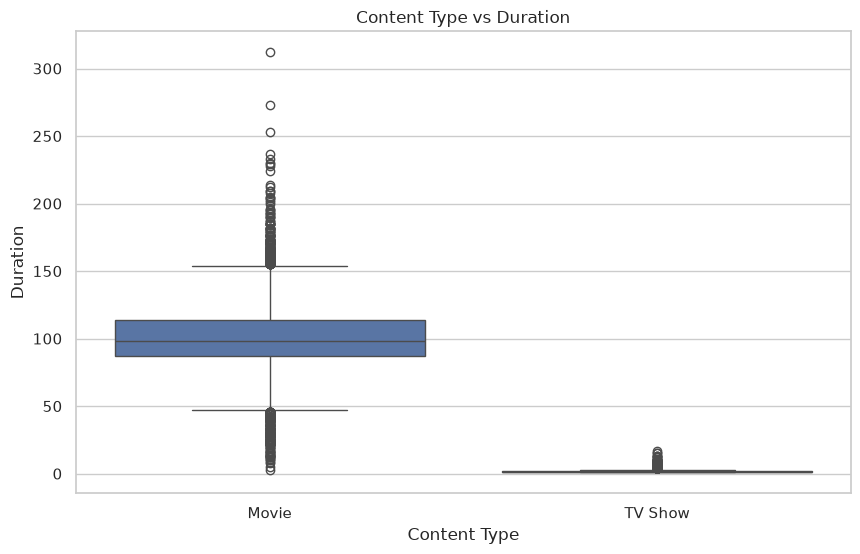

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="type",
    y="duration_value"
)

plt.title("Content Type vs Duration")
plt.xlabel("Content Type")
plt.ylabel("Duration")
plt.show()

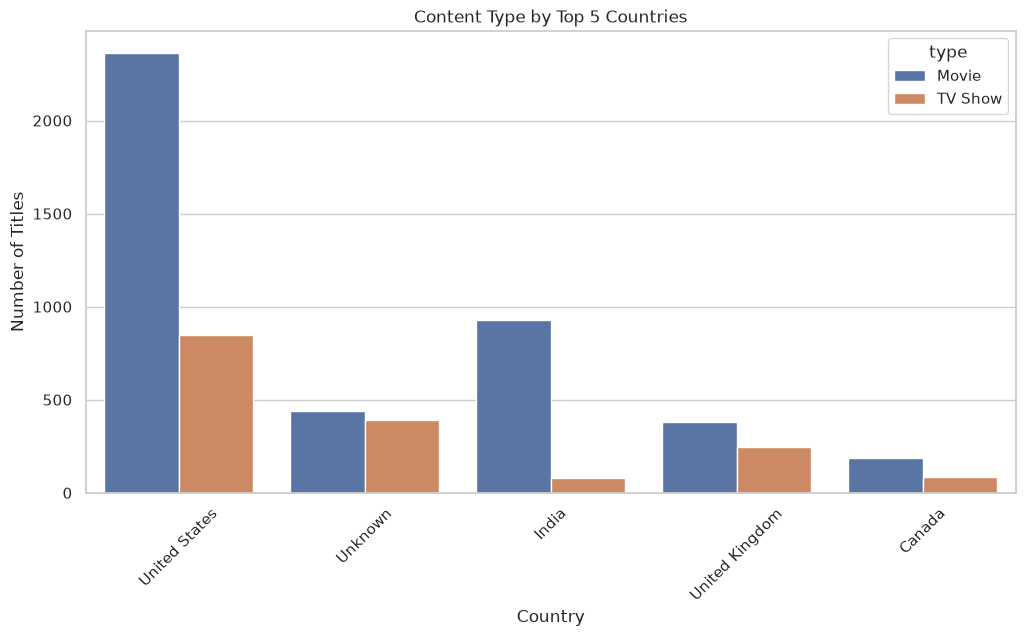

In [ ]:
top_countries_list = (
    eda_df["primary_country"]
    .value_counts()
    .head(5)
    .index
)

multi_df = eda_df[
    eda_df["primary_country"].isin(top_countries_list)
]

plt.figure(figsize=(12, 6))

sns.countplot(
    data=multi_df,
    x="primary_country",
    hue="type"
)

plt.title("Content Type by Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

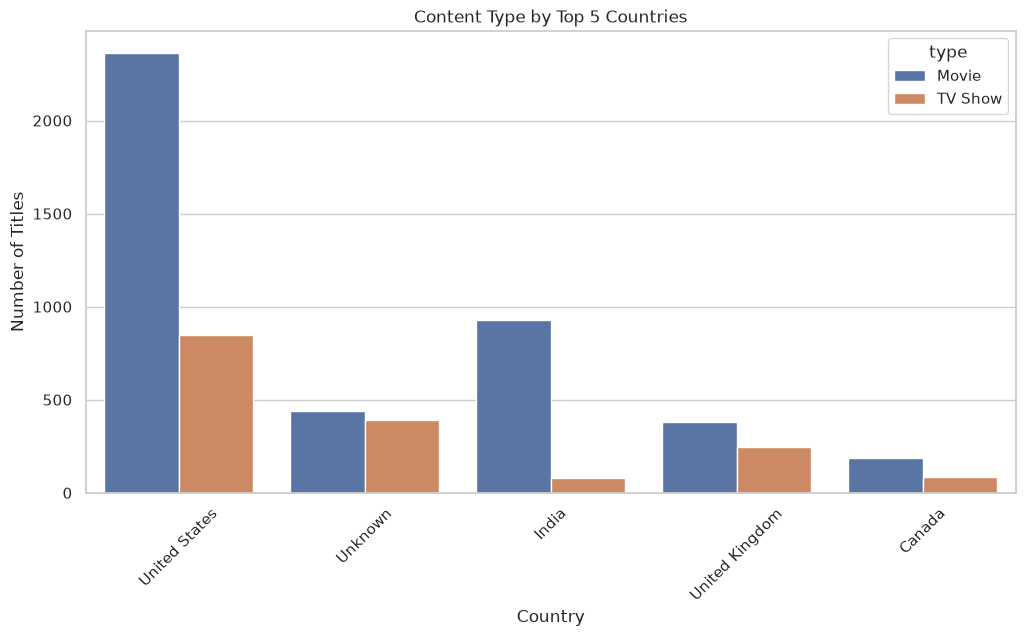

In [ ]:
top_countries_list = (
    eda_df["primary_country"]
    .value_counts()
    .head(5)
    .index
)

multi_df = eda_df[
    eda_df["primary_country"].isin(top_countries_list)
]

plt.figure(figsize=(12, 6))

sns.countplot(
    data=multi_df,
    x="primary_country",
    hue="type"
)

plt.title("Content Type by Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Content Type Counts:")
print(eda_df["type"].value_counts())

Content Type Counts:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [ ]:
print("Top 10 Countries:")
print(eda_df["primary_country"].value_counts().head(10))

Top 10 Countries:
primary_country
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64


In [ ]:
print("Top Release Years:")
print(eda_df["release_year"].value_counts().head(10))

Top Release Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


In [ ]:
print("Top Ratings:")
print(eda_df["rating"].value_counts().head(10))

Top Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


## EDA Summary

The Netflix dataset was explored using descriptive statistics and multiple
visualization techniques. The analysis included:

- Dataset dimensions and structure
- Data types and summary statistics
- Missing-value and duplicate-value analysis
- Numerical distributions using histograms and density plots
- Categorical analysis using count plots and bar charts
- Correlation analysis using a heatmap
- Outlier detection using box plots
- Relationship analysis using scatter plots
- Univariate analysis
- Bivariate analysis
- Multivariate analysis

The analysis helps identify patterns in Netflix content, understand the
distribution of movies and TV shows, examine content duration, identify
important countries and ratings, and observe relationships between numerical
features.


## Questions and Answers

### Question 1. What is Exploratory Data Analysis (EDA), and why is it performed before machine learning?

**Answer:**

Exploratory Data Analysis (EDA) is the process of examining, summarizing, and visualizing a dataset to understand its structure, patterns, relationships, distributions, and anomalies.

EDA is performed before machine learning because it helps to:

* Understand the characteristics of the dataset.
* Identify missing values and duplicate records.
* Detect outliers and unusual observations.
* Understand the distribution of variables.
* Identify relationships and correlations between features.
* Detect data quality problems.
* Decide which features may be useful for building a model.
* Select appropriate preprocessing and transformation techniques.

Therefore, EDA helps ensure that the data is suitable for further analysis and machine learning.

---

### Question 2. Differentiate between univariate, bivariate, and multivariate analysis with suitable examples.

**Answer:**

The three types of analysis differ according to the number of variables being studied.

| Type of Analysis          | Meaning                                            | Example                                                     |
| ------------------------- | -------------------------------------------------- | ----------------------------------------------------------- |
| **Univariate Analysis**   | Analysis of a single variable                      | Studying the distribution of Netflix content ratings        |
| **Bivariate Analysis**    | Analysis of two variables and their relationship   | Studying the relationship between release year and duration |
| **Multivariate Analysis** | Analysis of three or more variables simultaneously | Comparing content type, country, and number of titles       |

**Univariate analysis** focuses on one variable and can use histograms, bar charts, or summary statistics.

**Bivariate analysis** examines the relationship between two variables and can use scatter plots, box plots, or grouped bar charts.

**Multivariate analysis** examines multiple variables together and can use heatmaps, grouped visualizations, or other multidimensional techniques.

---

### Question 3. What insights can be obtained from a correlation heatmap?

**Answer:**

A correlation heatmap provides a visual representation of the correlation between numerical variables.

It can help identify:

* **Positive correlation**, where two variables tend to increase together.
* **Negative correlation**, where one variable tends to increase as the other decreases.
* **Weak or no correlation**, where there is little relationship between variables.
* **Highly correlated features**, which may provide similar information.
* Possible **multicollinearity** between features in predictive models.

The strength of the relationship is generally represented by a correlation coefficient ranging from **-1 to +1**.

A value close to **+1** indicates strong positive correlation, a value close to **-1** indicates strong negative correlation, and a value close to **0** indicates little or no linear correlation.

However, correlation alone does not prove that one variable causes another.

---

### Question 4. Explain the purpose of histograms, box plots, and scatter plots in EDA.

**Answer:**

**Histogram:**
A histogram is used to understand the distribution of a numerical variable. It shows how frequently different ranges of values occur. It helps identify the center, spread, skewness, and general shape of the distribution.

**Box Plot:**
A box plot summarizes the distribution of a numerical variable using the median, quartiles, and range. It is particularly useful for identifying potential outliers and comparing distributions across different categories.

**Scatter Plot:**
A scatter plot shows the relationship between two numerical variables. It helps identify positive or negative relationships, clusters, trends, and unusual observations.

Thus, these three visualizations provide different but complementary views of numerical data during EDA.

---

### Question 5. How can EDA help identify data quality issues before analysis?

**Answer:**

EDA can reveal several data quality problems before analysis or machine learning begins.

It can help identify:

* Missing values.
* Duplicate records.
* Incorrect or inconsistent data types.
* Invalid or unusual values.
* Outliers.
* Inconsistent category names.
* Unexpected distributions.
* Skewed numerical variables.
* Errors in data entry.

For example, functions such as `isnull()`, `duplicated()`, `info()`, and `describe()` can be used to inspect the dataset, while graphs can reveal unusual distributions and outliers.

Identifying these problems early improves the reliability and accuracy of subsequent analysis.

---

### Question 6. Why is correlation important in predictive analytics? Can correlation imply causation?

**Answer:**

Correlation is important in predictive analytics because it helps identify relationships between variables. Highly correlated features may provide useful information for predicting a target variable, while strongly correlated input features may also indicate multicollinearity.

Correlation can therefore help with:

* Feature selection.
* Understanding relationships between variables.
* Detecting redundant features.
* Improving interpretation of predictive models.

However, **correlation does not imply causation**.

Two variables may be correlated because of a third variable, coincidence, or another underlying factor. Therefore, finding a strong correlation does not necessarily mean that a change in one variable causes a change in the other.

---

### Question 7. Which visualization would you use to analyze categorical and numerical variables? Justify your choice.

**Answer:**

The choice of visualization depends on whether the variables are categorical or numerical.

For a **categorical variable**, a **bar chart or count plot** is appropriate because it clearly shows the frequency of each category.

For a **numerical variable**, a **histogram** is useful because it shows the distribution and spread of numerical values.

When analyzing a **categorical variable together with a numerical variable**, a **box plot** is a good choice. It allows us to compare the distribution of the numerical variable across different categories and identify potential outliers.

For example, in the Netflix dataset:

* A **count plot** can compare Movies and TV Shows.
* A **histogram** can show the distribution of content duration.
* A **box plot** can compare duration between Movies and TV Shows.

These visualizations make patterns easier to understand than looking at raw values alone.

---

### Question 8. What business insights can be derived from the Netflix (or Superstore/HR Analytics) dataset through EDA?

**Answer:**

From the Netflix dataset, EDA can provide several useful business insights, such as:

* The proportion of Movies compared with TV Shows.
* The countries contributing the largest number of titles.
* The most common content ratings.
* Trends in the number of titles released over different years.
* The distribution of content duration.
* Differences in content characteristics between Movies and TV Shows.
* Frequently occurring genres and categories.
* Changes in the type and quantity of content over time.

These insights can help a streaming business understand its content library and make better decisions regarding content acquisition, production, and audience targeting.

---

### Question 9. How does EDA contribute to feature selection and model building?

**Answer:**

EDA contributes to feature selection and model building by helping us understand which variables are useful and which may cause problems.

During EDA, we can:

* Identify relevant features.
* Detect irrelevant or redundant variables.
* Examine correlations between features.
* Identify features containing many missing values.
* Detect outliers that may affect model performance.
* Understand variable distributions.
* Identify categorical variables that require encoding.
* Determine whether numerical features require transformation or scaling.

This information allows better preprocessing and helps create a more suitable set of features for machine learning.

As a result, EDA can improve model quality, interpretability, and reliability.

---

### Question 10. What challenges might arise while performing EDA on large-scale real-world datasets?

**Answer:**

Several challenges can arise when performing EDA on large-scale real-world datasets.

Some major challenges are:

* **Large data volume:** Processing huge datasets can require significant memory and computing resources.
* **Missing data:** Large datasets may contain many incomplete records.
* **Inconsistent data:** Different sources may use different formats, naming conventions, or units.
* **High dimensionality:** A large number of variables makes analysis and visualization more difficult.
* **Outliers and noise:** Large datasets may contain many unusual or incorrect observations.
* **Processing time:** Statistical calculations and visualizations can become slower as the dataset grows.
* **Visualization limitations:** Plotting millions of observations directly may be inefficient or difficult to interpret.

Therefore, large-scale EDA often requires efficient data-processing techniques, sampling, aggregation, and appropriate visualization methods.
